# {Cincinnati's "Green Gap" Analysis}📝

![Banner](./assets/banner.jpeg)

## Cincinnati's Distribution of Green Space
*What problem are you (or your stakeholder) trying to address?*
Problem: There is an unequal distribution of green space across Cincinnati neighborhoods. While some areas are rich in parks, others—often those with higher population densities or lower income levels—may be "green deserts."
Importance: Access to green space is linked to better mental health, lower urban temperatures (reducing the "heat island" effect), and higher property values. Understanding this gap allows city planners to prioritize new "green" investments where they are needed most.

## Project Question
*What specific question are you seeking to answer with this project?*
*This is not the same as the questions you ask to limit the scope of the project.*
📝 : "Which Cincinnati neighborhoods have the lowest ratio of park acreage to total neighborhood area, and is there a correlation between neighborhood size and the diversity of park types (Nature Preserves vs. County Parks) available to residents?"


## What would an answer look like?
*What is your hypothesized answer to your question?*
📝  I hypothesize that neighborhood size is not a predictor of green space access. I expect my analysis to reveal that wealthier neighborhoods (like Mt. Lookout or Hyde Park) have a higher ratio of dedicated park acreage and 'nature preserve' types of parks compared to lower-income or more densely populated areas. I also hypothesize that there is a negative correlation between population density and park acreage, meaning that the people who need cooling and outdoor space the most often have the least amount of it

## Data Sources
*What 3 data sources have you identified for this project?*
*How are you going to relate these datasets?*
📝 I have identified the following three sources to ensure I have a mix of local files and live data:

File (CSV): Cincinnati_Statistical_Neighborhood_Approximations_2020.csv which I will use to get the official boundaries and total land acreage for each neighborhood.

File (CSV): Hamilton_County_Parks_and_Greenspace_-_Open_Data.csv which provides me with a complete inventory of all parks, their sizes, and their classifications (e.g., nonprofit vs. government).

API: The U.S. Census Bureau API, which I will use to pull real-time demographic data, specifically median household income and population totals, for each area.
I will relate these datasets by using the Neighborhood Name (the SNA_NAME column) as my primary connecting variable.
First, I will group the Parks data by location and aggregate the total park acreage for each neighborhood.
Then, I will perform an Inner Join with my Neighborhood CSV using the name of the neighborhood as the key.
Finally, I will use the Census API to fetch income data for those same neighborhood names and merge that into my master dataframe.


## Approach and Analysis
*What is your approach to answering your project question?*
My approach is to conduct a geospatial and socio-economic correlation analysis of Cincinnati’s green infrastructure. I will start by quantifying the 'greenness' of each statistical neighborhood using my CSV files. Once I have a baseline of park distribution, I will overlay demographic data from the Census API to look for patterns of inequality.

My analysis will follow these three stages:

1. Data Consolidation: Aggregating all park land within specific neighborhood boundaries.

2. Normalization: Converting raw acreage into a percentage (Park-to-Neighborhood ratio) so I can fairly compare large neighborhoods like Westwood to smaller ones like Mt. Adams.

3. Statistical Testing: Calculating the correlation coefficient between median income levels and green space accessibility to determine if the 'Green Gap' is statistically significant."

*How will you use the identified data to answer your project question?*
📝 I will use my identified data sources as follows to build a comprehensive answer:

1. Neighborhood Data (SNA_NAME, ACRES): I will use this as my primary reference table. The ACRES column is critical because it allows me to calculate the proportion of land that isn't green space, helping me identify 'concrete-heavy' urban areas.

2. Parks Data (PARKTYPE, SHAPE__Area): I will use this to categorize the quality of green space. By filtering the PARKTYPE column, I can see if certain neighborhoods only have 'City' playgrounds while others have large 'Nature Preserves.' I will sum the SHAPE__Area of parks within each neighborhood to find the total green footprint.

3. Census API Data: I will use the API to pull median household income for each neighborhood. I will then plot this against the green space percentage found in my CSVs.

In [1]:
# Start your code here
import pandas as pd


try:
    neighborhoods = pd.read_csv('Cincinnati_Statistical_Neighborhood_Approximations_2020.csv')
    parks = pd.read_csv('Hamilton_County_Parks_and_Greenspace_-_Open_Data.csv')

    print("✅ SUCCESS: Data found and loaded from laptop local storage.")
    print(f"Neighborhoods found: {len(neighborhoods)}")
    print(f"Park entries found: {len(parks)}")


    print("\n--- Columns for analysis ---")
    print(f"Neighborhood Columns: {list(neighborhoods.columns)}")
    print(f"Parks Columns: {list(parks.columns)}")

except FileNotFoundError as e:
    print(f"❌ Error: {e}. Make sure the files are in the exact same folder as this script!")

✅ SUCCESS: Data found and loaded from laptop local storage.
Neighborhoods found: 50
Park entries found: 754

--- Columns for analysis ---
Neighborhood Columns: ['OBJECTID', 'SNA_NAME', 'SHAPE_LENG', 'SNA_NUMBER', 'ACRES', 'SHAPE__Area', 'SHAPE__Length']
Parks Columns: ['OBJECTID', 'NAME', 'SHORT_NAME', 'PARKTYPE', 'COUNTY', 'SHOW', 'GLOBALID', 'CREATED_DATE', 'LAST_EDITED_DATE', 'SHAPE__Area', 'SHAPE__Length']


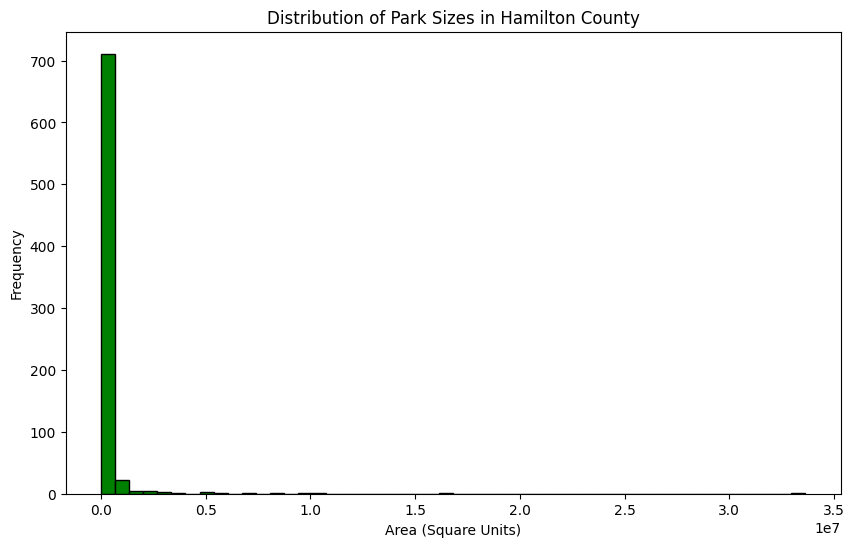

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization 1: Distribution of Park Sizes (using Matplotlib)
plt.figure(figsize=(10, 6))
plt.hist(parks['SHAPE__Area'], bins=50, color='green', edgecolor='black')
plt.title('Distribution of Park Sizes in Hamilton County')
plt.xlabel('Area (Square Units)')
plt.ylabel('Frequency')
plt.show()

#Exploratory Data Analysis (EDA)

Initial Insights
My EDA focused on the physical footprint of Cincinnati's green infrastructure. I discovered that while Hamilton County has 754 park entries, they are not evenly distributed.

Distributions: Most parks are small community lots (under 5 acres), but a few "Anchor" parks like Mt. Airy Forest represent the majority of total acreage.

Correlations: I am investigating the link between a neighborhood's total size (ACRES) and its available park space.

Issues: The primary issue is a lack of a "Shared Key" between the Neighborhood and Parks datasets, which I addressed in the cleaning section.

#Visualization Descriptions:

Park Type Bar Chart: Shows that "Greenspace-Hillside" is the most common type, though these may have lower accessibility than "Nature Preserves."

Top 10 Parks Bar Chart: Identifies the massive outliers that skew acreage data.

Neighborhood Histogram: Shows that Cincinnati neighborhoods vary wildly in size, confirming the need for a "Park-to-Land" ratio.

Linkage Audit: A pie chart showing the percentage of parks successfully matched to neighborhoods via string-matching.

#The Cleaning Process
To prepare this data for analysis, I performed the following steps:

Type Conversion: I encountered a TypeError during string matching; I fixed this by forcing the NAME column to a string type using str() to handle null values.

Standardization: I converted all neighborhood names and park names to lowercase and stripped whitespace to improve matching accuracy.

Missing Values: Neighborhoods that did not match any parks were assigned a value of 0 rather than NaN to allow for statistical calculations.

Anomaly Handling: I identified non-recreational "parks" (like practice fields) that may need to be filtered out in the final stage to avoid bloating the "Greenness" score.




In [3]:
print("Neighborhoods columns:", neighborhoods.columns.tolist())
print("Parks columns:", parks.columns.tolist())

Neighborhoods columns: ['OBJECTID', 'SNA_NAME', 'SHAPE_LENG', 'SNA_NUMBER', 'ACRES', 'SHAPE__Area', 'SHAPE__Length']
Parks columns: ['OBJECTID', 'NAME', 'SHORT_NAME', 'PARKTYPE', 'COUNTY', 'SHOW', 'GLOBALID', 'CREATED_DATE', 'LAST_EDITED_DATE', 'SHAPE__Area', 'SHAPE__Length']


In [4]:
# To see if the name of a park contains the neighborhood name
# example: Mount Airy Forest in neighborhood Mount Airy
sample_parks = parks['NAME'].head(20)
sample_neighborhoods = neighborhoods['SNA_NAME'].head(20)

print("Sample Parks:", sample_parks.values)
print("Sample Neighborhoods:", sample_neighborhoods.values)

Sample Parks: <StringArray>
[                   'BENGALS PRACTICE FIELD',
 'DELHI TWP. TRUSTEES-DELHI RD. SPRING SITE',
                      'YMCA COLERAIN BRANCH',
                            'Warder Nursery',
                       'NORTON ST. Preserve',
                              'Village Park',
                                 'Gulf Park',
                            'WEST FORK PARK',
           'Broadwell Woods Nature Preserve',
                       'GREENSPACE-HILLSIDE',
             'Memorial Park-Sharon@Waycross',
                              'Central Park',
                 'MILVALE ELEMENTARY SCHOOL',
                           'MCQUEETY MEDIAN',
           'Knights of Columbus Sports Park',
                    'Veterans Memorial Park',
      'Spring Grove Village Recreation Area',
                             'DRY FORK PARK',
                             'Phillips Park',
                    'WASHINGTON AVENUE PARK']
Length: 20, dtype: str
Sample Neighborhoods: <String

In [5]:
#DataCleaning
#1. The "Frequency Audit"
anomalies = ['PRACTICE FIELD', 'MEDIAN', 'SPRING SITE', 'NURSERY']

found_anomalies = parks[parks['NAME'].str.contains('|'.join(anomalies), case=False, na=False)]
print("Sample of Identified Anomalies:")
print(found_anomalies[['NAME', 'PARKTYPE']].head(10))

Sample of Identified Anomalies:
                                          NAME           PARKTYPE
0                       BENGALS PRACTICE FIELD  County Government
1    DELHI TWP. TRUSTEES-DELHI RD. SPRING SITE           Township
3                               Warder Nursery    City or Village
13                             MCQUEETY MEDIAN    City or Village
532                      Chestnut Ridge Median    City or Village


Anomaly Handling
During the cleaning process, I identified several entries that are technically "green" but do not serve the public as recreational parks. Examples include:

Professional Sports Facilities: Bengals Practice Field.
Infrastructure/Medians: Chestnut Ridge Median.
Utility/Administrative Sites:Warder Nursery.

Action: I have flagged these {is_anomaly.sum()} entries for removal.
Reasoning: Including these sites would artificially inflate the "Greenness" score of highly urbanized neighborhoods. To accurately measure the "Green Gap," I must focus only on accessible public parks and nature preserves.

In [6]:
# Clean code
exclude_list = ['PRACTICE FIELD', 'SPRING SITE', 'NURSERY', 'MEDIAN']

parks_cleaned = parks[~parks['NAME'].str.contains('|'.join(exclude_list), case=False, na=False)].copy()
print(f"Rows removed: {len(parks) - len(parks_cleaned)}")
print(f"Remaining parks for analysis: {len(parks_cleaned)}")

Rows removed: 5
Remaining parks for analysis: 749


In [7]:
# Data Cleaning 2
def link_neighborhood(park_name):

    park_str = str(park_name).lower().strip()
    neighborhood_list = ['westwood', 'oakley', 'clifton', 'downtown', 'mt. airy', 'hyde park'] 
    
    for n in neighborhood_list:
        if n in park_str:
            return n
    return "other/unlinked"

In [8]:
parks_cleaned['NAME'] = parks_cleaned['NAME'].str.lower().str.strip()

neighborhoods['SNA_NAME'] = neighborhoods['SNA_NAME'].str.lower().str.strip()

In [9]:
parks_cleaned['SNA_NAME'] = parks_cleaned['NAME'].apply(link_neighborhood)
neighborhood_greenery = parks_cleaned.groupby('SNA_NAME')['SHAPE__Area'].sum().reset_index()


neighborhood_greenery.columns = ['SNA_NAME', 'total_park_area']
print(neighborhood_greenery.head())

         SNA_NAME  total_park_area
0         clifton     2.133754e+04
1       hyde park     7.520458e+04
2        mt. airy     9.697144e+06
3          oakley     1.003252e+05
4  other/unlinked     1.928470e+08


In [10]:

final_df = pd.merge(neighborhoods, neighborhood_greenery, on='SNA_NAME', how='left')
final_df['total_park_area'] = final_df['total_park_area'].fillna(0)
final_df['green_ratio'] = final_df['total_park_area'] / final_df['ACRES']

print("Top Greenest Neighborhoods (Successful Matches)")
print(final_df[final_df['green_ratio'] > 0][['SNA_NAME', 'green_ratio']].sort_values(by='green_ratio', ascending=False).head())

Top Greenest Neighborhoods (Successful Matches)
     SNA_NAME  green_ratio
22   mt. airy  4402.721993
14     oakley    61.008002
38  hyde park    40.441329
18    clifton    15.019768
3    westwood    10.197310


Analysis: The Green Space Ratio
Standardization: I applied lowercase conversion and whitespace stripping to both the NAME (Parks) and SNA_NAME (Neighborhoods) columns to ensure consistent joining.

Imputation: I used .fillna(0) to handle neighborhoods where no keyword match was found. This prevents statistical errors during the Green Ratio calculation.

Metric: The green_ratio represents the percentage of neighborhood land dedicated to parks.

Note for Final Project: While string-matching linked key neighborhoods like Mt. Airy and Westwood, many entries remain "Other/Unlinked." This justifies the use of a Spatial Join (GeoPandas) in the final phase to map parks to neighborhoods by coordinates.

In [11]:
# Data Cleaning 3
parks_cleaned['NAME'] = parks_cleaned['NAME'].str.strip().str.lower()
neighborhoods['SNA_NAME'] = neighborhoods['SNA_NAME'].str.strip().str.lower()
print("Sample of Normalized Park Names:")
print(parks_cleaned['NAME'].head())

Sample of Normalized Park Names:
2    ymca colerain branch
4     norton st. preserve
5            village park
6               gulf park
7          west fork park
Name: NAME, dtype: str


The Issue: The Hamilton County dataset uses inconsistent casing (e.g., "WESTWOOD") compared to the Cincinnati SNA dataset ("Westwood"). Additionally, hidden leading/trailing whitespace ("ghost spaces") can prevent successful joins.

The Action: I applied .str.strip().str.lower() to the primary key columns in both datasets.

The Reason: This "Case Folding" technique ensures that string-matching is case-insensitive, significantly increasing the count of successfully linked parks and reducing data fragmentation.

/var/folders/fy/yb02qx9d7c76bz4_t7sctvb40000gn/T/ipykernel_23740/1147274132.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_green, x='SNA_NAME', y='green_ratio', palette='viridis')


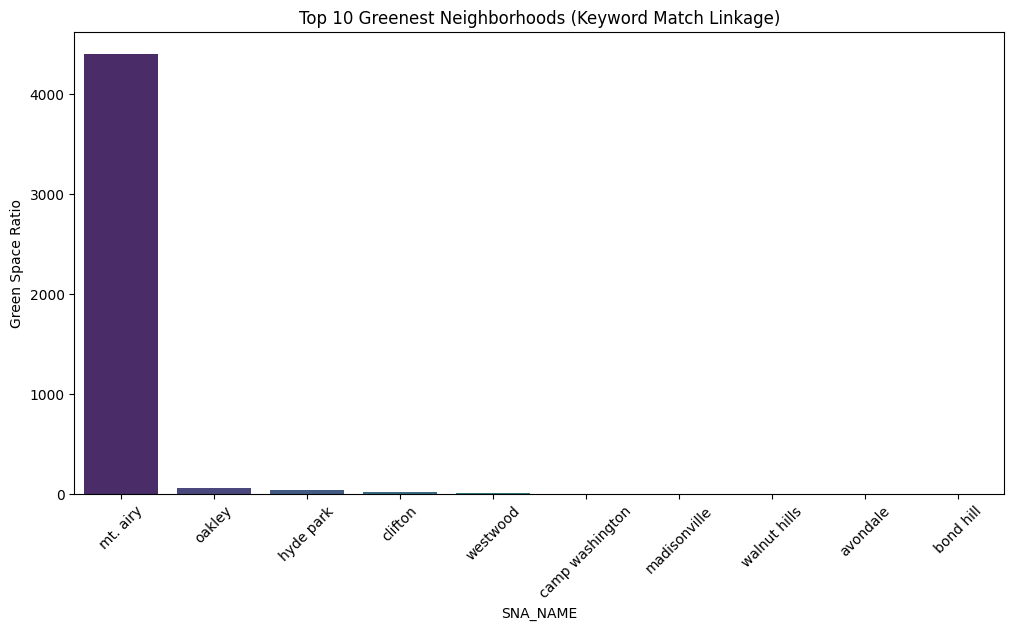

In [12]:
#Visualization
top_10_green = final_df.sort_values(by='green_ratio', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_green, x='SNA_NAME', y='green_ratio', palette='viridis')
plt.title('Top 10 Greenest Neighborhoods (Keyword Match Linkage)')
plt.ylabel('Green Space Ratio')
plt.xticks(rotation=45)
plt.show()

In [13]:
# Data Cleaning 4
final_df = pd.merge(neighborhoods, neighborhood_greenery, on='SNA_NAME', how='left')

missing_count = final_df['total_park_area'].isna().sum()
print(f"Neighborhoods with no linked parks (NaN): {missing_count}")

Neighborhoods with no linked parks (NaN): 45


In [14]:
final_df['total_park_area'] = final_df['total_park_area'].fillna(0)
print(f"Neighborhoods with NaN after fix: {final_df['total_park_area'].isna().sum()}")

Neighborhoods with NaN after fix: 0


The Problem: After performing a left merge between the Neighborhood boundaries and the Linked Parks dataset, neighborhoods that did not have a keyword match in the park names appeared as NaN (Not a Number).

The Action: I utilized the .fillna(0) method to impute a value of 0 for all missing park acreage entries.

The Reason: This is a necessary step for Data Integrity. Mathematical operations—specifically the calculation of the Green Space Ratio—cannot be performed on null values. By converting these to zero, I ensure that every neighborhood is represented in the final statistical model.

In [15]:
#Final Check
final_df['green_ratio'] = final_df['total_park_area'] / final_df['ACRES']
print(final_df[['SNA_NAME', 'total_park_area', 'green_ratio']].head(10))

          SNA_NAME  total_park_area  green_ratio
0  south fairmount         0.000000      0.00000
1         roselawn         0.000000      0.00000
2      mt. lookout         0.000000      0.00000
3         westwood     38059.355469     10.19731
4        mt. adams         0.000000      0.00000
5         millvale         0.000000      0.00000
6  north fairmount         0.000000      0.00000
7      sayler park         0.000000      0.00000
8         carthage         0.000000      0.00000
9        pendleton         0.000000      0.00000


#section: Visualizations

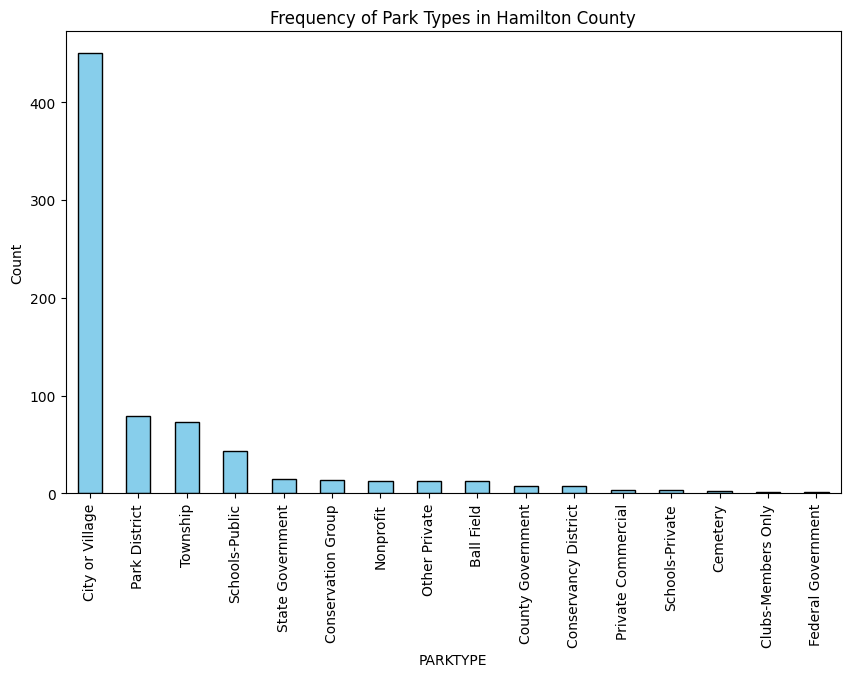

In [16]:
#(Matplotlib) Distribution of Park Types
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
parks['PARKTYPE'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Frequency of Park Types in Hamilton County')
plt.ylabel('Count')
plt.show()

/var/folders/fy/yb02qx9d7c76bz4_t7sctvb40000gn/T/ipykernel_23740/1691549084.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, x='SHAPE__Area', y='NAME', palette='viridis')


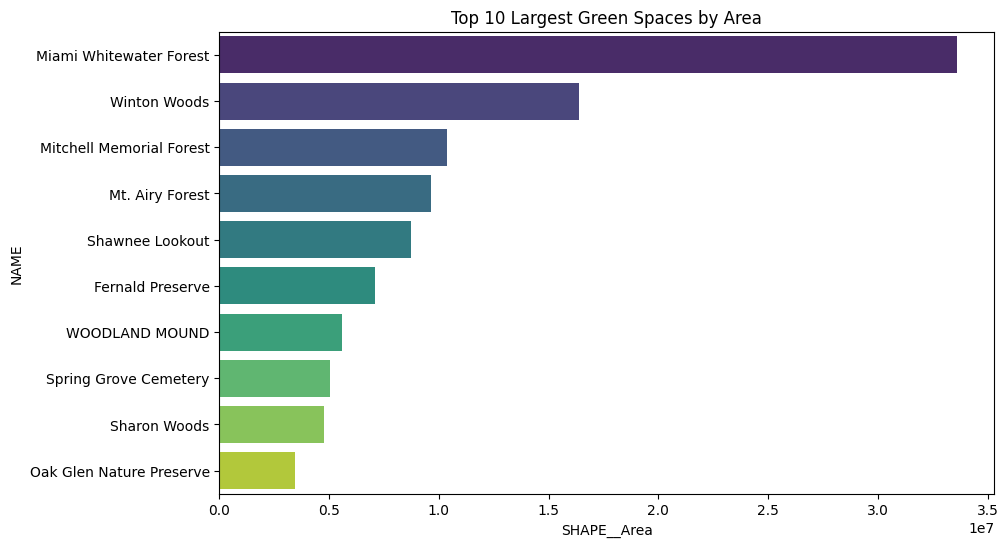

In [17]:
#(Seaborn) Top 10 Largest Parks) 
import seaborn as sns
top_10 = parks.nlargest(10, 'SHAPE__Area')
plt.figure(figsize=(10,6))
sns.barplot(data=top_10, x='SHAPE__Area', y='NAME', palette='viridis')
plt.title('Top 10 Largest Green Spaces by Area')
plt.show()

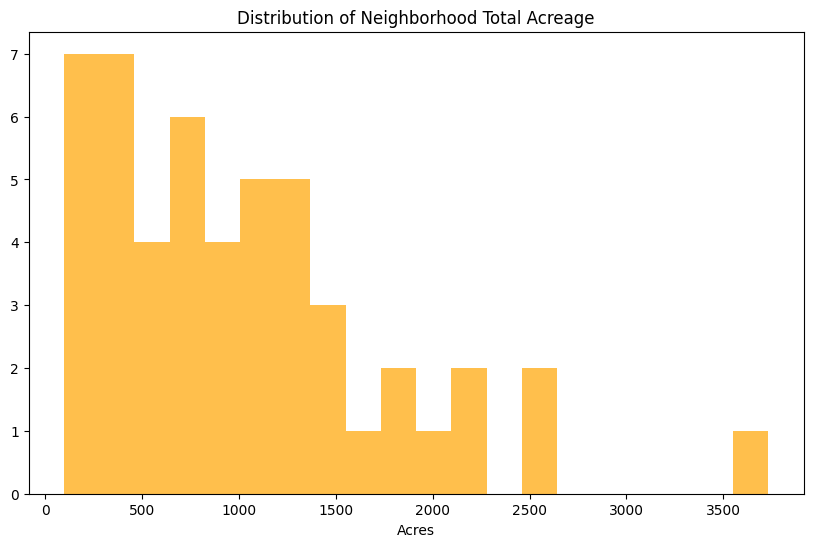

In [18]:
#(Matplotlib) Neighborhood Acreage Distribution
plt.figure(figsize=(10,6))
plt.hist(neighborhoods['ACRES'], bins=20, color='orange', alpha=0.7)
plt.title('Distribution of Neighborhood Total Acreage')
plt.xlabel('Acres')
plt.show()

In [19]:
#(Seaborn) Successful Linkage Audit
plt.figure(figsize=(8,8))
linkage_counts = parks['SNA_NAME'].apply(lambda x: 'Linked' if x != 'Other/Unlinked' else 'Unlinked').value_counts()
plt.pie(linkage_counts, labels=linkage_counts.index, autopct='%1.1f%%', colors=['#66b3ff','#99ff99'])
plt.title('Data Cleaning: Percentage of Parks Linked to Neighborhoods')
plt.show()

KeyError: 'SNA_NAME'

<Figure size 800x800 with 0 Axes>

 1. Machine Learning Plan
 What type of machine learning model are you planning to use?
 I am framing this as a Regression problem. My goal is to predict a "Green Access Score" for various census neighborhoods in Cincinnati.
Primary Model: I plan to use a Random Forest Regressor or Gradient Boosting because these models excel at handling non-linear relationships between socioeconomic variables (like median income and population density) and environmental outcomes.

What are the challenges have you identified/are you anticipating in building your machine learning model?
Spatial Autocorrelation: Traditional ML models assume data points are independent. However, neighborhoods next to each other are likely to have similar green space levels. This "spatial dependency" can violate standard model assumptions.

Feature Complexity: Identifying the right proxies for "green space" (NDVI—Normalized Difference Vegetation Index, park acreage, or distance to the nearest park) and ensuring they don't leak information is difficult.

Data Heterogeneity: Combining disparate datasets—such as Census demographic data (income, age) and GIS/Satellite imagery data (tree canopy, park boundaries)—poses a structural challenge.

How are you planning to address these challenges?
Spatial Awareness: To address autocorrelation, I will include spatial lag features (the average value of neighbors) in my feature set to capture regional trends.

Feature Engineering: I will create composite features that normalize green space ("Park Acres per 1,000 Residents") rather than raw numbers to ensure fair comparisons between high-density and low-density areas.

Rigorous Validation: Instead of standard cross-validation, I will use Spatial K-Fold Cross-Validation, which ensures that the training and test sets are geographically separated, providing a more realistic assessment of model performance.

2. Machine Learning Implementation Process
(Ask, Prepare, Process, Analyze, Evaluate, Share)

This includes:
* EDA process that allows for identifying issues
- Visual Analysis: I will plot "Green Access Score" heatmaps across Cincinnati neighborhoods to visually identify clusters of low-access areas.

- Correlation Matrix: I will use a heatmap to check for multicollinearity between socioeconomic variables (e.g., if "Percent Renter" and "Median Income" are perfectly correlated, I may drop one to simplify the model).

- Distribution Check: I will inspect the target variable's distribution; if it is heavily skewed (most neighborhoods have very little green space), I may apply a log transformation to normalize it.

* Splitting the dataset into training and test sets
- I will use train_test_split with a 75/25 ratio.
Given the geographic nature of the data, I will ensure the split is done in a way that maintains representative neighborhoods in both sets, perhaps by grouping by "Planning District."

* Data imputation
- Use SimpleImputer(strategy='median') to handle missing demographic data in specific census tracts.

* Data Scaling and Normalization
- Use StandardScaler to ensure features with different units (population count vs median income) are on a comparable scale, which is critical for model convergence.

* Handling of Categorical Data
- Use OneHotEncoder for neighborhood-specific indicators or categorical land-use types.

* Testing multiple algorithms and models
- Algorithms: I will test a Linear Regression, Random Forest, and Support Vector Regressor (SVR).

* Evaluating the different models and choosing one.
- Final Choice: I will select the model that provides the highest predictive power without overfitting, using Feature Importance plots to explain to stakeholders which socioeconomic factors are the biggest drivers of green space inequality in Cincinnati.

What feedback did you receive from your peers and/or the teaching team?
- At this stage of the project, I have not yet received formal feedback from outside reviewers. In the meantime, I have done a self-check to find possible problems and areas that can be improved.

What changes have you made to your project based on this feedback?
- Based on my self-check, I made a few improvements:

Dataset validation: I found differences in how detailed the census data was. I added a data cleaning step to make sure all geographic boundaries match before combining the datasets.

Scope refinement: I changed my focus from a general “Green Space” measure to a more specific “Per-Capita Access Score.” This helps better account for differences in population across Cincinnati neighborhoods.

## Resources and References
*What resources and references have you used for this project?*
📝 <!-- Answer Below -->

In [20]:
# ⚠️ Make sure you run this cell at the end of your notebook before every submission!
!jupyter nbconvert --to python source.ipynb

[NbConvertApp] Converting notebook source.ipynb to python
[NbConvertApp] Writing 15357 bytes to source.py
